# Compute $\langle r^2\rangle(L)$ at $\phi=0$ using EC back-rotation

In [1]:
from dvr import *

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
n_ecsystems = 1              # number of EC computations per phi
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
save_plots = True           # save plots or not


gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
# compute exact <r^2>(L)
exact_Ls = np.linspace(20.0, 50.0, 150)
exact_rrs = []

for L in exact_Ls:
    DVRtest = DVR(n, L, rotation_angle=phi, potential=gauss_s)
    _, eigstate = DVRtest.closest_to_resonance(real_res)
    rr = DVRtest.compute_r2(eigstate[:, 0], rotate_rr=True)
    exact_rrs.append(rr)

In [4]:
predict_Ls = np.linspace(20.0, 50.0, 20)
phi_training_range, num_phi_points = [pi/24, pi/6], 20
phi_predict = pi/24
predict_energies, predict_rrs, predict_rrs_err95, predict_rrs_err68 = [], [], [], []
for L in predict_Ls:
    # for each L in, construct EC ensemble and train all ECs
    EC_ensemble = ECEnsemble(n_ecsystems, n, L, real_res, potential=gauss_s)
    EC_ensemble.train(phi_training_range, num_phi_points)
    EC_ensemble.construct_bases(augment=None)

    # predict energies and rrs at phi=0
    predict_energies_atL, predict_rrs_atL, \
        predict_rrs_err95_atL, predict_rrs_err68_atL, \
        _, _ = EC_ensemble.extrapolate([phi_predict], rotate_rr=False)
    
    predict_energies.append(predict_energies_atL[0])
    predict_rrs.append(predict_rrs_atL[0])
    predict_rrs_err95.append(predict_rrs_err95_atL.T[0])
    predict_rrs_err68.append(predict_rrs_err68_atL.T[0])
predict_rrs_err95 = np.array(predict_rrs_err95).T
predict_rrs_err68 = np.array(predict_rrs_err68).T

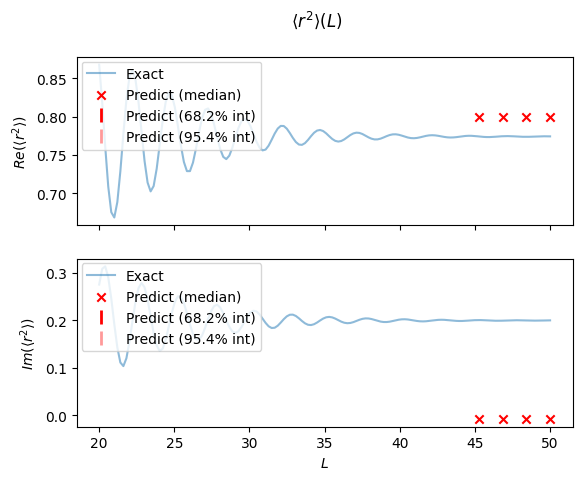

In [5]:
# plot results with error bands
cutoff = -4
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(exact_Ls, np.real(exact_rrs), alpha=0.5, label="Exact")
ax2.plot(exact_Ls, np.imag(exact_rrs), alpha=0.5, label="Exact")
ax1.scatter(predict_Ls[cutoff:], np.real(predict_rrs)[cutoff:], marker='x', c='red', label="Predict (median)")
ax2.scatter(predict_Ls[cutoff:], np.imag(predict_rrs)[cutoff:], c='red', marker='x', label="Predict (median)")
ax1.errorbar(predict_Ls[cutoff:], np.real(predict_rrs)[cutoff:],
            yerr=(np.real(predict_rrs_err68[0])[cutoff:], np.real(predict_rrs_err68[1])[cutoff:]),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax1.errorbar(predict_Ls[cutoff:], np.real(predict_rrs)[cutoff:],
            yerr=(np.real(predict_rrs_err95[0])[cutoff:], np.real(predict_rrs_err95[1])[cutoff:]),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
ax2.errorbar(predict_Ls[cutoff:], np.imag(predict_rrs)[cutoff:],
            yerr=(np.imag(predict_rrs_err68[0])[cutoff:], np.imag(predict_rrs_err68[1])[cutoff:]),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=1.0, label='Predict (68.2% int)')
ax2.errorbar(predict_Ls[cutoff:], np.imag(predict_rrs)[cutoff:],
            yerr=(np.imag(predict_rrs_err95[0])[cutoff:], np.imag(predict_rrs_err95[1])[cutoff:]),
            fmt='none', ecolor='red', elinewidth=2.0, alpha=.4, label='Predict (95.4% int)')
ax2.set_xlabel(r"$L$")
ax2.set_ylabel(r"$Im(\langle r^2 \rangle)$")
ax1.set_ylabel(r"$Re(\langle r^2 \rangle)$")
fig.suptitle(r"$\langle r^2\rangle(L)$")
ax1.legend(loc=(0.01,0.45))
ax2.legend(loc=(0.01,0.45))
if save_plots:
    plt.savefig(f"./plots/ec_backrot_radius__phitrain_{phi_training_range[0]:.3f}_{phi_training_range[1]:.3f}_{num_phi_points}__phipredict_{phi_predict:.3f}.png")
plt.show()

## Test to see if predictions get better without random sampling

In [7]:
phi_train = np.linspace(pi/24, pi/6, 50)
phi_predict = 1e-6
predict_Ls = np.linspace(35.0, 50.0, 20)
predict_rrs = []
for L in predict_Ls:
    EC_system = ECSystem(n, L, real_res, gauss_s)
    EC_system.train(phi_train)
    EC_system.construct_basis(verbose=False, augment=None)
    _, rrs = EC_system.predict([phi_predict], rotate_rr=False)
    predict_rrs.append(rrs[0])
predict_rrs = np.array(predict_rrs)

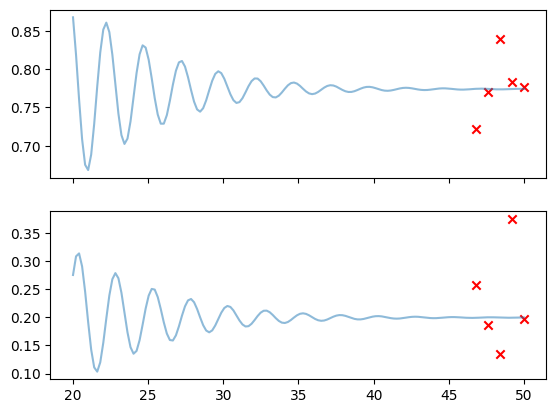

In [8]:
cutoff=-5
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(exact_Ls, np.real(exact_rrs), alpha=0.5, label="Exact")
ax2.plot(exact_Ls, np.imag(exact_rrs), alpha=0.5, label="Exact")
ax1.scatter(predict_Ls[cutoff:], np.real(predict_rrs)[cutoff:], marker='x', c='red', label="Predict")
ax2.scatter(predict_Ls[cutoff:], np.imag(predict_rrs)[cutoff:], c='red', marker='x', label="Predict")
plt.show()